# Linear regression of Etherium on Bitcoin prices

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In this notebook, we illustrate how to carry out a simple linear regression in scikit-learn. We will be using datasets of the daily prices of BTC and ETH which can be found below:

BTC Prices: https://www.kaggle.com/datasets/dannyrevaldo/bitcoin-price-weekly-update

ETH Prices: https://www.kaggle.com/datasets/dannyrevaldo/ethereum-price-weekly-update

## Data Processing

We first read in and take a look at our data.

In [8]:
btc = pd.read_csv('BTCPrices.csv')
btc.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,04/08/2024,"71,347.9","69,358.0","71,442.1","69,110.5",55.11K,2.87%
1,04/07/2024,"69,360.4","68,897.3","70,285.8","68,849.4",46.99K,0.68%
2,04/06/2024,"68,890.6","67,830.5","69,632.0","67,467.2",41.48K,1.56%
3,04/05/2024,"67,830.6","68,498.7","68,692.2","66,023.3",88.97K,-0.97%
4,04/04/2024,"68,496.5","65,968.4","69,238.8","65,096.3",100.30K,3.84%


Let's drop the unneccessary columns for our analysis. First we process the bitcoin prices.

In [9]:
btc.drop(['Open', 'High', 'Low', 'Vol.', 'Change %'], axis=1, inplace=True)
btc['Price'] = btc['Price'].str.replace(',', '').astype(float)
btc.head()

,Date,Price
0,04/08/2024,71347.9
1,04/07/2024,69360.4
2,04/06/2024,68890.6
3,04/05/2024,67830.6
4,04/04/2024,68496.5


Let's also process the ETH prices

In [10]:
eth = pd.read_csv('ETHPrices.csv')
eth.drop(['Open', 'High', 'Low', 'Vol.', 'Change %'], axis=1, inplace=True)
eth['Price'] = eth['Price'].str.replace(',', '').astype(float)
eth.head()

,Date,Price
0,04/08/2024,3569.99
1,04/07/2024,3454.17
2,04/06/2024,3352.03
3,04/05/2024,3317.84
4,04/04/2024,3327.45


We now merge these into a single dataframe and sort by the BTC price.

In [11]:
merged = pd.merge(btc, eth, on='Date', suffixes=['_btc', '_eth'])
merged.sort_values(by='Price_btc', inplace=True)

## Creating a linear model

We first plot the data to see if there really is a linear relationship.

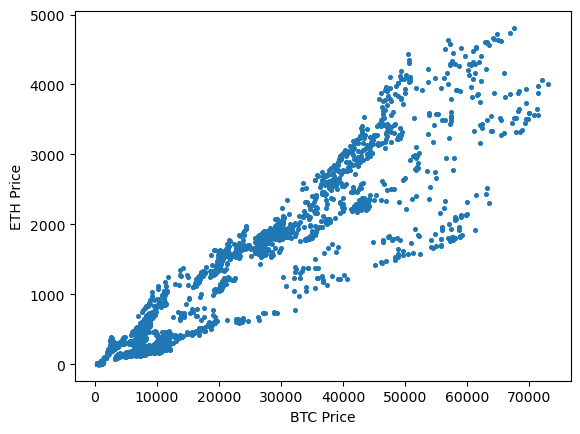

In [15]:
plt.scatter(merged['Price_btc'], merged['Price_eth'], s=7)
plt.xlabel('BTC Price')
plt.ylabel('ETH Price')
plt.show()

The relationship appears linear, there is a bit of heteroskedasticity but we can nevertheless proceed with the regression. Let's go ahead and fit a regression line to the data.

In [16]:
regressionLine = LinearRegression()
X = merged['Price_btc'].values.reshape(-1, 1)
regressionLine.fit(X, merged['Price_eth'])
predictions = regressionLine.predict(X)

Let's plot the data, together with the regression line to see how it looks. 

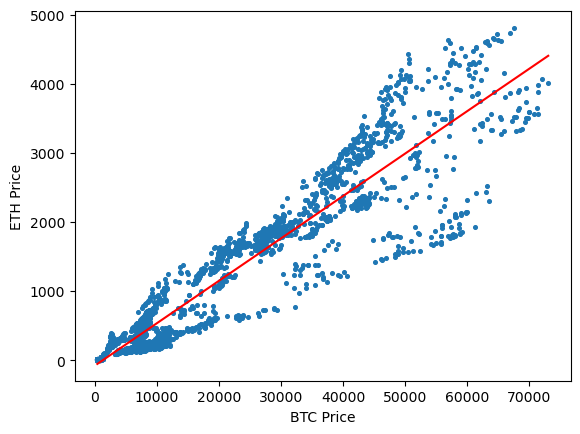

In [17]:
plt.scatter(merged['Price_btc'], merged['Price_eth'], s=7)
plt.plot(X, predictions, color = 'red')
plt.xlabel('BTC Price')
plt.ylabel('ETH Price')
plt.show()

Not bad! Finally, let's compute the $R^2$ coefficient of determination.

In [18]:
regressionLine.score(X, merged['Price_eth'])

0.8868556976564883